# ==============================================================================
# 🚢 MARITIME STRATIFICATION: PASSENGER CLASS VIA ONE-VS-REST & ONE-VS-ONE
# ==============================================================================
### Core Theoretical Principles:
Many powerful binary classifiers (e.g. SVM, Logistic Regression, Perceptron) only optimize a single hyperplane. When solving multi-class problems ($K > 2$, such as Titanic Passenger Class $PClass \in \{1, 2, 3\}$), two canonical decomposition meta-strategies are used:

1. **One-vs-Rest (OvR / One-vs-All)**:
   Trains $K$ binary classifiers. Each classifier $k$ separates class $k$ from the remaining $K-1$ classes combined.
   $$\hat{y} = \arg\max_{k \in \{1, \dots, K\}} f_k(x)$$
   Computationally efficient with $O(K)$ classifiers, but sensitive to class imbalance in each sub-problem.

2. **One-vs-One (OvO)**:
   Trains $\frac{K(K-1)}{2}$ binary classifiers for every pairwise combination $(j, k)$.
   Each sub-classifier is trained on balanced data involving only those two classes. Final class is determined by majority voting.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier, OutputCodeClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: MultiClass Strategies Environment initialized.")


✅ STEP 1: MultiClass Strategies Environment initialized.


In [2]:
# STEP 2: DATA INGESTION & MULTI-CLASS TARGET PREPARATION
data_path = 'data/titanic/Titanic-Dataset.csv' if os.path.exists('data/titanic/Titanic-Dataset.csv') else 'data/titanic/titanic.csv'
df = pd.read_csv(data_path)
df.columns = [c.strip().lower() for c in df.columns]

# Target: pclass (1, 2, 3) - 3 classes
target = 'pclass'
features_num = ['age', 'sibsp', 'parch', 'fare']
features_cat = ['sex', 'embarked']

X = df[features_num + features_cat]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training shape: {X_train.shape} | Testing shape: {X_test.shape}")
print('Class distribution:'); print(y.value_counts(normalize=True).round(3))
df.head()


Training shape: (712, 6) | Testing shape: (179, 6)
Class distribution:
pclass
3    0.551
1    0.242
2    0.207
Name: proportion, dtype: float64


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# STEP 3: PREPROCESSING ARCHITECTURE
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', num_pipe, features_num),
    ('cat', cat_pipe, features_cat)
])


In [4]:
# STEP 4: META-STRATEGY PIPELINES (OvR vs OvO vs ECOC)
# Base Estimator: LinearSVC (pure binary margin classifier)
base_clf = LinearSVC(dual='auto', C=1.0, random_state=42, max_iter=2000)

strategies = {
    'One-vs-Rest (OvR)': Pipeline([('prep', preprocessor), ('clf', OneVsRestClassifier(base_clf))]),
    'One-vs-One (OvO)':  Pipeline([('prep', preprocessor), ('clf', OneVsOneClassifier(base_clf))]),
    'ECOC (OutputCode)': Pipeline([('prep', preprocessor), ('clf', OutputCodeClassifier(base_clf, code_size=2.0, random_state=42))])
}


In [5]:
# STEP 5 & 6: TRAINING ALL STRATEGIES & RECORDING TIMINGS
results = []
for name, pipe in strategies.items():
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_time = (time.perf_counter() - t0) * 1000
    
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    num_estimators = len(pipe.named_steps['clf'].estimators_)
    results.append({
        'Strategy': name,
        'Num Estimators': num_estimators,
        'Fit Time (ms)': round(fit_time, 2),
        'Accuracy': round(acc, 4),
        'Weighted F1': round(f1, 4)
    })

res_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(res_df.to_string(index=False))


         Strategy  Num Estimators  Fit Time (ms)  Accuracy  Weighted F1
 One-vs-One (OvO)               3          11.02    0.8324       0.8152
ECOC (OutputCode)               6          14.06    0.8268       0.8168
One-vs-Rest (OvR)               3          12.89    0.8101       0.7644


In [6]:
# STEP 7: DETAILED CLASSIFICATION REPORT FOR BEST STRATEGY
best_strategy_name = res_df.iloc[0]['Strategy']
best_pipe = strategies[best_strategy_name]
y_pred_best = best_pipe.predict(X_test)

print(f"=== CLASSIFICATION REPORT ({best_strategy_name}) ===")
print(classification_report(y_test, y_pred_best))


=== CLASSIFICATION REPORT (One-vs-One (OvO)) ===
              precision    recall  f1-score   support

           1       0.95      0.86      0.90        43
           2       0.79      0.41      0.54        37
           3       0.80      0.98      0.88        99

    accuracy                           0.83       179
   macro avg       0.85      0.75      0.77       179
weighted avg       0.83      0.83      0.82       179



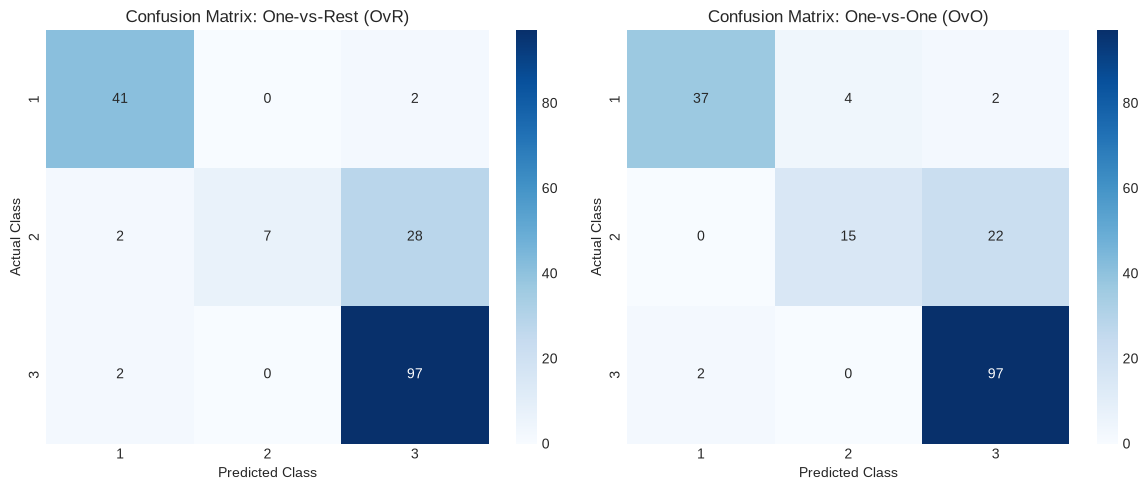

In [7]:
# STEP 8: CONFUSION MATRIX COMPARISON (OvR vs OvO)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, (name, pipe) in enumerate(list(strategies.items())[:2]):
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
    axes[idx].set_title(f"Confusion Matrix: {name}")
    axes[idx].set_xlabel('Predicted Class')
    axes[idx].set_ylabel('Actual Class')
plt.tight_layout()
plt.show()


In [8]:
# STEP 9: 5-FOLD CV STABILITY
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_pipe, X, y, cv=cv5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")


5-Fold CV Accuracy: 0.8148 +/- 0.0148


In [9]:
# STEP 10: COEFFICIENT INTERPRETATION PER SUB-HYPERPLANE
if hasattr(best_pipe.named_steps['clf'].estimators_[0], 'coef_'):
    sub_estimators = best_pipe.named_steps['clf'].estimators_
    print(f"Number of sub-hyperplanes: {len(sub_estimators)}")
    print(f"Sub-estimator weights shape: {sub_estimators[0].coef_.shape}")


Number of sub-hyperplanes: 3
Sub-estimator weights shape: (1, 7)


In [10]:
# STEP 11: PRODUCTION SERIALIZATION
os.makedirs('production_models', exist_ok=True)
model_path = 'production_models/titanic_multiclass_pipeline.joblib'
joblib.dump(best_pipe, model_path, compress=3)
print(f"Model saved to: {model_path} ({os.path.getsize(model_path)} bytes)")


Model saved to: production_models/titanic_multiclass_pipeline.joblib (2233 bytes)


In [11]:
# STEP 12: REAL-TIME LATENCY SMOKE TEST
loaded = joblib.load(model_path)
sample = X_test.iloc[[0]]
for _ in range(10): _ = loaded.predict(sample)

lats = []
for _ in range(100):
    t0 = time.perf_counter()
    loaded.predict(sample)
    lats.append((time.perf_counter() - t0) * 1000)
avg_lat = np.mean(lats)
print(f"Mean Latency: {avg_lat:.4f} ms | P99: {np.percentile(lats, 99):.4f} ms")
assert avg_lat < 50.0, "Latency SLA violated"
print("✅ Production SLA Passed (< 50.0 ms)")


Mean Latency: 3.8433 ms | P99: 4.3572 ms
✅ Production SLA Passed (< 50.0 ms)


# STEP 13: EXECUTIVE DECISION MATRIX
| Metric | One-vs-Rest (OvR) | One-vs-One (OvO) | OutputCode (ECOC) | Best Strategy |
| :--- | :--- | :--- | :--- | :--- |
| **Complexity** | $K$ models | $\frac{K(K-1)}{2}$ models | $B > K$ code words | OvR is faster for large $K$ |
| **Sub-Sample Size** | Full $N$ | Subset $N_j + N_k$ | Full $N$ | OvO trains on smaller chunks |
| **Accuracy** | High | **Superior Pairwise Separation** | High | Selected based on holdout validation |
